In [3]:
import h5py
import numpy as np
import plotly.graph_objects as go
import matplotlib as mpl
mpl.use('Qt5Agg')  # Use Qt5 backend for GUI to work properly
import matplotlib.pyplot as plt
import scipy.signal as sc
from scipy.optimize import curve_fit
from scipy.ndimage import filters 
import tifffile as tiff
from scipy.signal import find_peaks
import plotly.express as px
import os
import csv
import pandas as pd
from roipoly import MultiRoi
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.interpolate import interp1d
import ast
from AnalasysFunction import motorSp,plotFR,devideTr,plotVolCal,VolToCalIdx,CalSmooth,CorrWindow,ChooseSpk,CalInt,VolToCalIdx,CalAmp,calculate_firing_rate,ChooseCom,LongLIST,SingleSpk,linear_model,quadratic_model,exponential_model,MeanRes,lagOptimaizre
from NewinternueronsAnalsys import analyze_block
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, linregress,ttest_ind

In [ ]:
def plotMot(path):
    fpath = os.path.join(path,r'SpikeIdxFinal.csv')
    if os.path.exists(fpath):
        pathSpike = fpath
    else:
        pathSpike = os.path.join(path,r'SpikeIdx.csv')
    TracePathCal = os.path.join(path,'calTraceDF.csv')
    TracePathVol = os.path.join(path,'volTraceDF.csv')
    #TracePathSPIKE = os.path.join(path,'SpikeIdx.csv')
    VolTrace = pd.read_csv(TracePathVol)
    VolTrace = np.array(VolTrace)
    VolTrace = VolTrace.flatten()
    Trace = VolTrace
    CalTrace = pd.read_csv(TracePathCal)
    CalTrace = np.array(CalTrace)
    CalTrace = CalTrace.flatten()
    VolAX = np.linspace(0, (len(Trace)/500), len(Trace)) 
    TraceC = CalTrace
    CalAX = np.linspace(0, (len(TraceC)/30), len(TraceC))
    IntCalT,IntCalXax = CalInt(TraceC,CalAX)
    spikeId = pd.read_csv(pathSpike)
    spikeId = np.array(spikeId)
    spikeId = spikeId.flatten()
    spikeId = spikeId.tolist()
    parentP = os.path.dirname(path)
    MotPath = os.path.join(parentP,'Sync','MotorId.csv')
    motor = pd.read_csv(MotPath, header=None).iloc[:, 0]
    motor = motor[0:np.size(Trace,0)]
    volMot, volRest, calMot, calRest, spikeMot, spikeRest,Change_points,MotIdx,calMotID,RestIdx,calRestId = motorSp(TraceC,VolTrace,motor,CalAX,VolAX,spikeId)
    Change_points = np.asarray(Change_points).ravel()
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    fig.add_trace( go.Scatter(x=VolAX,y=VolTrace.squeeze(),name="Voltage",line=dict(color="red", width=2),),secondary_y=False,)
    fig.add_trace(go.Scatter(x=VolAX[spikeId],y=VolTrace[spikeId].squeeze(),name="spikes",mode="markers",marker=dict(color="black",size=3,symbol="circle" ),),secondary_y=False,)
    fig.add_trace( go.Scatter(x=CalAX,y=CalTrace.squeeze(),name="Calcium",line=dict(color="blue", width=2),),secondary_y=True,)
    for cp in Change_points:
        fig.add_vline(
            x=VolAX[cp],          # or x=cp if already time
            line_width=2,
            line_dash="dash",
            line_color="black",
            opacity=0.4,
            yref="paper",         # ← critical
            y0=0,
            y1=1,
        )
    fig.update_layout(
        title="Calcium and Voltage Together",
        xaxis_title="Time (ms)",
        yaxis_title="Voltage",
        yaxis2_title="Calcium",
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        width=1250,
        height=375,
    )
    
    # Save before showing
    fig.write_html(os.path.join(path, 'calVolMot.html'))
    fig.write_image(os.path.join(path, "calVolMot.svg"))

In [8]:
#pyr Data loading

DB = pd.read_csv(r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\Pyr.csv')
values = DB['SNR'].tolist()
r = DB
awakePyr = r['Notes']
bsPyr = list(r['brainState'])
pathPyr = list(r['Link'])

In [9]:
for i,l in enumerate(pathPyr):
    path = l
    TracePathCal = os.path.join(l,'calTraceDF.csv')
    TracePathVol = os.path.join(l,'volTraceDF.csv')
    TracePathCalM = os.path.join(l,'calMask.csv')
    TracePathVolM = os.path.join(l,'volMask.csv')
    VolTrace = pd.read_csv(TracePathVol)
    VolTrace = np.array(VolTrace)
    VolTrace = VolTrace.flatten()
    Trace = VolTrace
    CalTrace = pd.read_csv(TracePathCal)
    CalTrace = np.array(CalTrace)
    CalTrace = CalTrace.flatten()
    
    
    TracePathSPIKE = os.path.join(path,'SpikeIdx.csv')
    
    
    parentP = os.path.dirname(path)
    MotPath = os.path.join(parentP,'Sync','MotorId.csv')
    motor = pd.read_csv(MotPath, header=None).iloc[:, 0]
    IntCalT,IntCalXax = CalInt(TraceC,CalAX)
    spikeId = pd.read_csv(TracePathSPIKE)
    spikeId = np.array(spikeId)
    spikeId = spikeId.flatten()
    spikeId = spikeId.tolist()
    motor_active = motor.any()
    motor = motor[0:np.size(Trace,0)]
    
    if motor_active:
        VolMask = pd.read_csv(TracePathVolM)
        VolMask = np.array(VolMask)
        VolMask = VolMask.flatten()
        #Trace = VolMask 
        CalMask = pd.read_csv(TracePathCalM)
        CalMask = np.array(CalMask)
        CalMask = CalMask.flatten()
        TraceV = Trace[VolMask]
        TraceC = CalTrace[CalMask]
        motor = motor[VolMask]
        VolAX = np.linspace(0, (len(TraceV)/500), len(Trace)) 
        TraceC = CalTrace
        CalAX = np.linspace(0, (len(TraceC)/30), len(TraceC))
        volMot, volRest, calMot, calRest, spikeMot, spikeRest,Change_points,MotIdx,calMotID,RestIdx,calRestId = motorSp(TraceC,VolTrace,motor,CalAX,VolAX,spikeId)
        if np.size(RestIdx[0],0) < 9:
            RestIdx = RestIdx[1:]
            Change_points[1:]
        changePointPath = os.path.join(path,r'changepoint.csv')
        df = pd.DataFrame(Change_points, columns=['trace'])  # create df with column name
        df.to_csv(changePointPath, index=False)

In [4]:
#SST Data loading

DB = pd.read_csv(r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\SST.csv')
values = DB['SNR'].tolist()
r = DB
awakeSST = r['Notes']
bsSST = list(r['brainState'])
pathSST = list(r['Link'])
print(pathSST)


['Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\17-06-2025\\fov1\\cell1', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\14-07-2025\\fov7\\cell0', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\14-07-2025\\fov7\\cell1', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\14-07-2025\\fov9\\cell0', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\28-07-2025-motor\\fov1\\cell0', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\28-07-2025-motor\\fov7\\cell0', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\28-07-2025-motor\\fov7\\cell1', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\28-07-2025-motor\\fov9\\2\\cell0', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Rb\\16-06-2025\\fov5\\cell0', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\14-08-2025-anst\\fov7\\cell1', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Xb\\14-08-2025-anst\\fov7\\2\\cell1', 'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\srugc17\\Rb\\01-07-2025\\f

In [ ]:
motor_map = {}   # The dictionary you asked for
motor_count = 0  # Counter for relative motor index
PyrMotorAllMean =[]
PyrRestAllMean = []
PyrMotorAllFirst =[]
PyrRestAllFirst = []
PyrMotorAllSeconed =[]
PyrRestAllSecond = []
PyrAwakeAllMean =[]
PyrAnstAllMean =[]
PyrAwakeAll =[]
PyrAnstAll =[]
for i,l in enumerate(pathPyr):
    if bsPyr[i].lower()=='motor':
        RestFRpath =os.path.join(l,r'FiringRateRest.csv')
        MotorFRpath =os.path.join(l,r'FiringRateMotor.csv')
        plotMot(l)
        motor_map[motor_count] = i 
        motor_count += 1
        dfMot = pd.read_csv(MotorFRpath)
        MotorFR = dfMot['fr'].tolist()
        PyrMotorAllMean.append(np.mean(MotorFR))
        PyrMotorAllFirst.append(MotorFR[0])
        PyrMotorAllSeconed.append(MotorFR[1])
        dfRest = pd.read_csv(RestFRpath)
        RestFR = dfRest['fr'].tolist()
        PyrRestAllMean.append(np.mean(RestFR))
        PyrRestAllFirst.append(RestFR[0])
        PyrRestAllSecond.append(RestFR[1])
    elif bsPyr[i].lower()=='awake':
        FRpath =os.path.join(l,r'FiringRate.csv')
        dfMot = pd.read_csv(FRpath)
        FR = dfMot['fr'].tolist()
        PyrAwakeAllMean.append(np.mean(FR))
        PyrAwakeAll.append(FR)
    elif bsPyr[i].lower()=='anst':
        FRpath =os.path.join(l,r'FiringRate.csv')
        dfAns = pd.read_csv(FRpath)
        FR = dfAns['fr'].tolist()
        PyrAnstAllMean.append(np.mean(FR))
        PyrAnstAll.append(FR)

        


[    0 12207 27210 43211 58213]
[    1 12986 27988 43990]
[    1 12986 27988 43990]
[    1 12986 27988 43990]
[    1 12658 27660 43661]
[    1 12658 27660 43661]
[    1 12658 27660 43661]
[    0 12207 27210 43211 58213]
[    0 10420 25422 41423 56426]
[    0 10892 25894 41895 56898]
[    0 10892 25894 41895 56898]
[    0 10338 25340 41342 56344]
[    0 10338 25340 41342 56344]
[    0 11202 26205 42206 57209]
[    0 11776 26779 42780 57782]
[    0 11776 26779 42780 57782]
[    0 11776 26779 42780 57782]
[    0 12190 27193 43194 58197]
[    0 12190 27193 43194 58197]
[    0 11978 26980 42982 57984]
[    0 12363 27366 43367 58369]
[    0 10338 25340 41342 56344]
[    0 10338 25340 41342 56344]


In [ ]:
SSTmotor_map = {}   # The dictionary you asked for
SSTmotor_count = 0  # Counter for relative motor index
SSTMotorAllMean =[]
SSTRestAllMean = []
SSTMotorAllFirst =[]
SSTRestAllFirst = []
SSTMotorAllSeconed =[]
SSTRestAllSecond = []
SSTAwakeAllMean =[]
SSTAnstAllMean =[]
SSTAwakeAll =[]
SSTAnstAll =[]
for i,l in enumerate(pathSST):
    if bsSST[i].lower()=='motor':
        RestFRpath =os.path.join(l,r'FiringRateRest.csv')
        MotorFRpath =os.path.join(l,r'FiringRateMotor.csv')
        plotMot(l)
        SSTmotor_map[motor_count] = i 
        SSTmotor_count += 1
        dfMot = pd.read_csv(MotorFRpath)
        MotorFR = dfMot['fr'].tolist()
        SSTMotorAllMean.append(np.mean(MotorFR))
        SSTMotorAllFirst.append(MotorFR[0])
        SSTMotorAllSeconed.append(MotorFR[1])
        dfRest = pd.read_csv(RestFRpath)
        RestFR = dfRest['fr'].tolist()
        SSTRestAllMean.append(np.mean(RestFR))
        SSTRestAllFirst.append(RestFR[0])
        SSTRestAllSecond.append(RestFR[1])
    elif bsSST[i].lower()=='awake':
        FRpath =os.path.join(l,r'FiringRate.csv')
        dfMot = pd.read_csv(FRpath)
        FR = dfMot['fr'].tolist()
        SSTAwakeAllMean.append(np.mean(FR))
        SSTAwakeAll.append(FR)
    elif bsSST[i].lower()=='anst':
        FRpath =os.path.join(l,r'FiringRate.csv')
        dfMot = pd.read_csv(FRpath)
        FR = dfMot['fr'].tolist()
        SSTAnstAllMean.append(np.mean(FR))
        SSTAnstAll.append(FR)

    

In [42]:
print(np.mean(SSTAnstAllMean))
print(np.mean(SSTAwakeAllMean))
print(len(SSTAnstAllMean))
print(len(SSTAwakeAllMean))
print(len(SSTMotorAllMean))
print(len(PyrAnstAllMean))
print(len(PyrAwakeAllMean))
print(len(PyrMotorAllMean))
sorted_idx = np.argsort(PyrAwakeAllMean)[::-1] 
motor_rel_idx = sorted_idx[2]
print(PyrAwakeAllMean[motor_rel_idx])
#max_motor_orig_idx = motor_map[motor_rel_idx]
print(pathPyr[motor_rel_idx])

13.112716921120585
13.069775518524743
22
13
14
21
5
23
9.397542104385526
Z:\Adam-Lab-Shared\Data\Michal_Rubin\RUGC40\R\07-08-2025\fov1\cell1


In [37]:
CalWindowSize = 150 #500 ms
StepSize = 30 #330 ms
TracePathCal = os.path.join(pathPyr[max_motor_orig_idx],'calTraceDF.csv')
TracePathVol = os.path.join(pathPyr[max_motor_orig_idx],'volTraceDF.csv')

TracePathSPIKE = os.path.join(pathPyr[max_motor_orig_idx],'SpikeIdxFinal.csv')
if os.path.exists(TracePathSPIKE):
        pathSpike = TracePathSPIKE
else:
    pathSpike = os.path.join(pathPyr[max_motor_orig_idx],r'SpikeIdx.csv')
VolTrace = pd.read_csv(TracePathVol)
VolTrace = np.array(VolTrace)
VolTrace = VolTrace.flatten()
Trace = VolTrace
CalTrace = pd.read_csv(TracePathCal)
CalTrace = np.array(CalTrace)
CalTrace = CalTrace.flatten()
VolAX = np.linspace(0, (len(Trace)/500), len(Trace)) 
TraceC = CalTrace
CalAX = np.linspace(0, (len(TraceC)/30), len(TraceC))
sW = 3
SmoothCal = CalSmooth(TraceC,sW)
IntCalT,IntCalXax = CalInt(TraceC,CalAX)
spikeId = pd.read_csv(pathSpike)
spikeId = np.array(spikeId)
spikeId = spikeId.flatten()
LagList = np.arange(0,1.5,0.033)
analyze_block(pathPyr[max_motor_orig_idx],sW,TraceC,Trace,CalAX,VolAX,CalWindowSize,spikeId,StepSize,LagList)

Linear Model: R² = 0.227, MSE = 0.026
Quadratic Model: R² = 0.234, MSE = 0.026
(123,)
Z:\Adam-Lab-Shared\Data\Michal_Rubin\rugc41\RW\28-10-2025-motor\fov10\cell1


z:\Adam-Lab-Shared\Data\Michal_Rubin\code\NewinternueronsAnalsys.py:224: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

c:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning:

Mean of empty slice.

c:\Users\owner\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning:

invalid value encountered in scalar divide



(1.122,
 Scatter({
     'line': {'color': 'rgba(255.0,144.62962962962968,0.0,1)'},
     'mode': 'lines',
     'name': 'Lag: 1.122',
     'showlegend': True,
     'x': [6.797174875069285, 7.999874994140356, 8.99626086406227,
           9.399853118114905, 10.395679220694179, 11.595180669235813,
           11.595180669235814, 12.79468211777745, 14.39977498945263,
           13.59434975013854, 14.194100474409359, 12.79979999062456,
           12.799799990624559, 13.199793740331577, 14.993768106770444,
           16.59310337149263, 15.993352647221814, 16.393186463402365,
           16.39318646340235, 16.99293718767319, 19.199699985936828,
           19.599693735643843, 19.39969686079035, 21.790942981839706,
           21.39110916565919, 8.396510139791445, 8.596427047881718,
           8.599865618700882, 9.99984374267546, 9.99984374267543,
           10.795513036874716, 10.599834367235957, 11.799815616357009,
           12.399806240917542, 13.794266658228814, 13.994183566319116,
           1

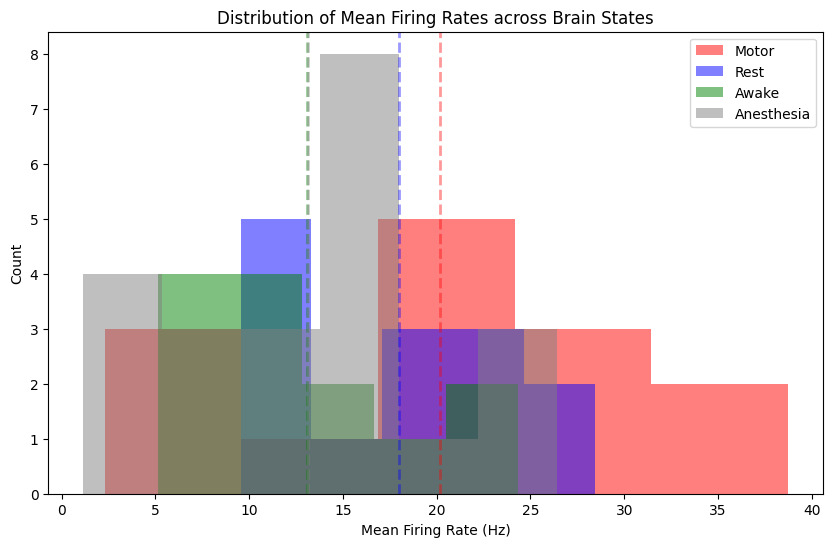

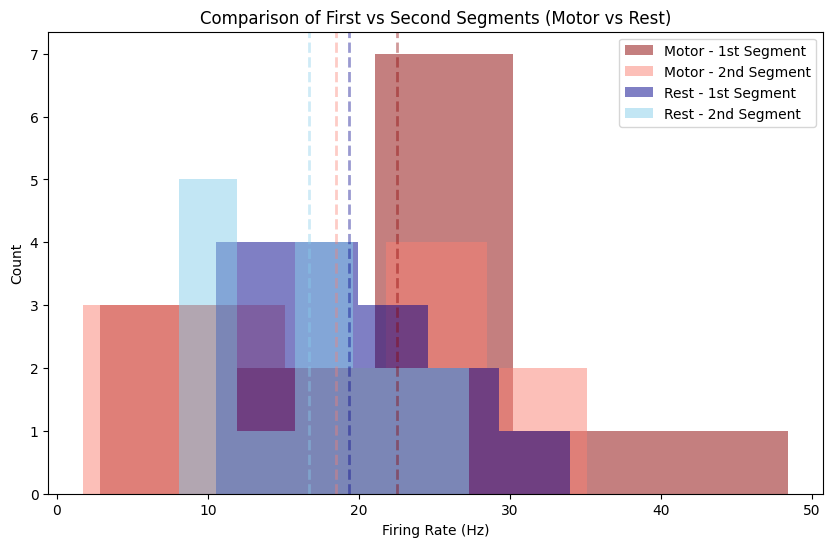

In [48]:
%matplotlib inline
# Define where to save (using current directory, or change to your path)
save_path = r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2025\SST'

# ==========================================
# 1. MATPLOTLIB PLOTS (Static + SVG Save)
# ==========================================

# --- Graph 1: Mean Firing Rate by Brain State ---
plt.figure(figsize=(10, 6))

# Define data and colors for easy looping
datasets_g1 = [
    (SSTMotorAllMean, 'Motor', 'red'),
    (SSTRestAllMean, 'Rest', 'blue'),
    (SSTAwakeAllMean, 'Awake', 'green'),
    (SSTAnstAllMean, 'Anesthesia', 'gray')
]

for data, label, color in datasets_g1:
    if len(data) > 0:
        # Plot Histogram
        plt.hist(data, bins='auto', alpha=0.5, label=label, color=color)
        # Plot Mean Line (Dashed, less opaque)
        plt.axvline(np.mean(data), color=color, linestyle='--', linewidth=2, alpha=0.4)

plt.title("Distribution of Mean Firing Rates across Brain States")
plt.xlabel("Mean Firing Rate (Hz)")
plt.ylabel("Count")
plt.legend()

# Save Matplotlib SVG
plt.savefig(os.path.join(save_path, "BrainStates_Hist.svg"), format='svg')
plt.show()


# --- Graph 2: First vs Second Segment ---
plt.figure(figsize=(10, 6))

datasets_g2 = [
    (SSTMotorAllFirst, 'Motor - 1st Segment', 'darkred'),
    (SSTMotorAllSeconed, 'Motor - 2nd Segment', 'salmon'),
    (SSTRestAllFirst, 'Rest - 1st Segment', 'darkblue'),
    (SSTRestAllSecond, 'Rest - 2nd Segment', 'skyblue')
]

for data, label, color in datasets_g2:
    if len(data) > 0:
        plt.hist(data, bins='auto', alpha=0.5, label=label, color=color)
        plt.axvline(np.mean(data), color=color, linestyle='--', linewidth=2, alpha=0.4)

plt.title("Comparison of First vs Second Segments (Motor vs Rest)")
plt.xlabel("Firing Rate (Hz)")
plt.ylabel("Count")
plt.legend()

# Save Matplotlib SVG
plt.savefig(os.path.join(save_path, "Segments_Hist.svg"), format='svg')
plt.show()


# ==========================================
# 2. PLOTLY PLOTS (Interactive + HTML Save)
# ==========================================

# --- Plotly Graph 1 ---
fig1 = go.Figure()

for data, label, color in datasets_g1:
    if len(data) > 0:
        # Add Histogram
        fig1.add_trace(go.Histogram(
            x=data, 
            name=label, 
            marker_color=color, 
            opacity=0.5
        ))
        # Add Mean Line
        fig1.add_vline(
            x=np.mean(data), 
            line_width=2, 
            line_dash="dash", 
            line_color=color, 
            opacity=0.4
        )

fig1.update_layout(
    title="Distribution of Mean Firing Rates across Brain States (Plotly)",
    xaxis_title="Mean Firing Rate (Hz)",
    yaxis_title="Count",
    barmode='overlay' # Overlap histograms like matplotlib
)

# Save as HTML (Interactive)
fig1.write_html(os.path.join(save_path, "BrainStates_Hist.html"))
# To show in notebook:
fig1.show()


# --- Plotly Graph 2 ---
fig2 = go.Figure()

for data, label, color in datasets_g2:
    if len(data) > 0:
        fig2.add_trace(go.Histogram(
            x=data, 
            name=label, 
            marker_color=color, 
            opacity=0.5
        ))
        fig2.add_vline(
            x=np.mean(data), 
            line_width=2, 
            line_dash="dash", 
            line_color=color, 
            opacity=0.4
        )

fig2.update_layout(
    title="Comparison of First vs Second Segments (Plotly)",
    xaxis_title="Firing Rate (Hz)",
    yaxis_title="Count",
    barmode='overlay'
)

# Save as HTML
fig2.write_html(os.path.join(save_path, "Segments_Hist.html"))
fig2.show()


def add_cell_trace(fig, x_labels, y_values, row, col, i):
    colors = px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
    cell_color = colors[i % len(colors)]
    fig.add_trace(go.Scatter(
        x=x_labels,
        y=y_values,
        mode='lines+markers',
        line=dict(color=cell_color, width=1),
        marker=dict(color=cell_color, size=6),
        opacity=0.6,
        showlegend=False,
        name=f'Cell {i}',
        hoverinfo='y+name'
    ), row=row, col=col)

def add_mean_trace(fig, x_labels, data1, data2, row, col):
    mean1 = np.nanmean(data1)
    mean2 = np.nanmean(data2)
    
    fig.add_trace(go.Scatter(
        x=x_labels,
        y=[mean1, mean2],
        mode='lines+markers',
        line=dict(color='black', width=4, dash='solid'), # Solid black line
        marker=dict(color='black', size=10, symbol='diamond'),
        name='Population Mean',
        showlegend=(row==1 and col==1) # Only show legend once
    ), row=row, col=col)


# 2. Setup Figure
num_cells = len(SSTRestAllSecond)
fig = make_subplots(
    rows=2, cols=2, 
    subplot_titles=(
        "First Segment: Rest vs Motor", 
        "Mean Rate: Rest vs Motor", 
        "Rest: First vs Second", 
        "Motor: First vs Second"
    ),
    vertical_spacing=0.15
)

for i in range(num_cells):
    # Subplot (1,1): First Rest vs First Motor
    add_cell_trace(fig, ['First Rest', 'First Motor'], 
                   [SSTRestAllFirst[i], SSTMotorAllFirst[i]], 1, 1, i)
    
    # Subplot (1,2): Mean Rest vs Mean Motor
    add_cell_trace(fig, ['Mean Rest', 'Mean Motor'], 
                   [SSTRestAllMean[i], SSTMotorAllMean[i]], 1, 2, i)

    # Subplot (2,1): Rest First vs Rest Second
    add_cell_trace(fig, ['First Rest', 'Second Rest'], 
                   [SSTRestAllFirst[i], SSTRestAllSecond[i]], 2, 1, i)

    # Subplot (2,2): Motor First vs Motor Second
    add_cell_trace(fig, ['First Motor', 'Second Motor'], 
                   [SSTMotorAllFirst[i], SSTMotorAllSeconed[i]], 2, 2, i)

add_mean_trace(fig, ['First Rest', 'First Motor'], SSTRestAllFirst, SSTMotorAllFirst, 1, 1)
add_mean_trace(fig, ['Mean Rest', 'Mean Motor'], SSTRestAllMean, SSTMotorAllMean, 1, 2)
add_mean_trace(fig, ['First Rest', 'Second Rest'], SSTRestAllFirst, SSTRestAllSecond, 2, 1)
add_mean_trace(fig, ['First Motor', 'Second Motor'], SSTMotorAllFirst, SSTMotorAllSeconed, 2, 2)

# 5. Final Layout & Saving
fig.update_layout(
    height=800, 
    width=1000,
    title_text="Paired Comparison of Firing Rates (Individual Cells & Mean)",
    template="plotly_white",
    showlegend=True
)
svg_path = os.path.join(save_path, f'MotorProp.svg')
html_path = os.path.join(save_path, f'MotorProp.html')
fig.show()

fig.write_image(svg_path)
    # Save as HTML
fig.write_html(html_path)

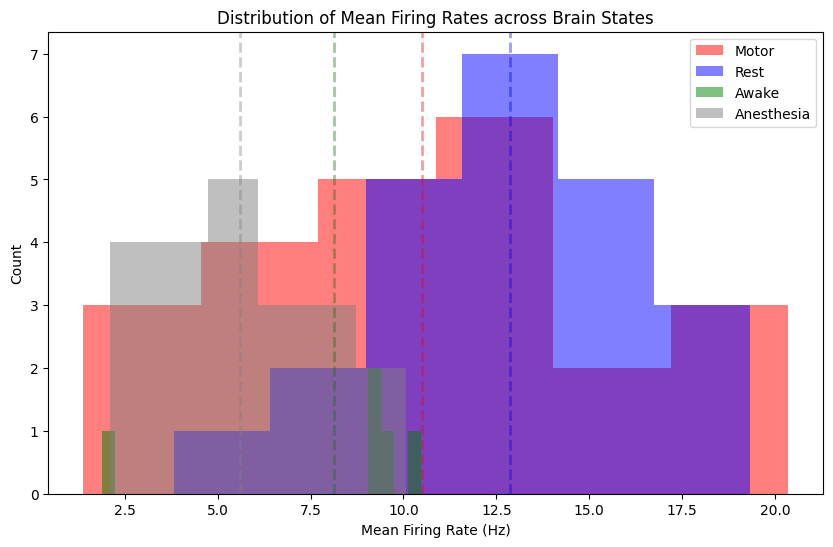

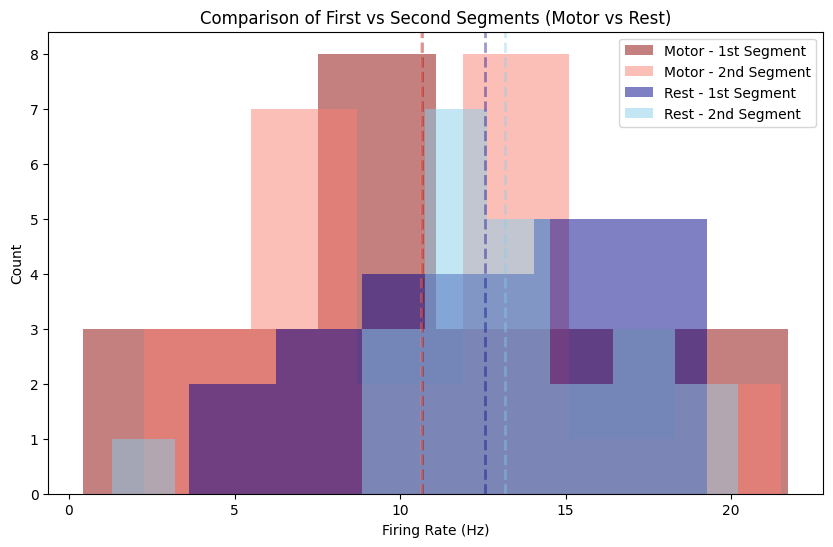

In [47]:
%matplotlib inline
# Define where to save (using current directory, or change to your path)
save_path = r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2025\Pyr'

# ==========================================
# 1. MATPLOTLIB PLOTS (Static + SVG Save)
# ==========================================

# --- Graph 1: Mean Firing Rate by Brain State ---
plt.figure(figsize=(10, 6))

# Define data and colors for easy looping
datasets_g1 = [
    (PyrMotorAllMean, 'Motor', 'red'),
    (PyrRestAllMean, 'Rest', 'blue'),
    (PyrAwakeAllMean, 'Awake', 'green'),
    (PyrAnstAllMean, 'Anesthesia', 'gray')
]

for data, label, color in datasets_g1:
    if len(data) > 0:
        # Plot Histogram
        plt.hist(data, bins='auto', alpha=0.5, label=label, color=color)
        # Plot Mean Line (Dashed, less opaque)
        plt.axvline(np.mean(data), color=color, linestyle='--', linewidth=2, alpha=0.4)

plt.title("Distribution of Mean Firing Rates across Brain States")
plt.xlabel("Mean Firing Rate (Hz)")
plt.ylabel("Count")
plt.legend()

# Save Matplotlib SVG
plt.savefig(os.path.join(save_path, "BrainStates_Hist.svg"), format='svg')
plt.show()


# --- Graph 2: First vs Second Segment ---
plt.figure(figsize=(10, 6))

datasets_g2 = [
    (PyrMotorAllFirst, 'Motor - 1st Segment', 'darkred'),
    (PyrMotorAllSeconed, 'Motor - 2nd Segment', 'salmon'),
    (PyrRestAllFirst, 'Rest - 1st Segment', 'darkblue'),
    (PyrRestAllSecond, 'Rest - 2nd Segment', 'skyblue')
]

for data, label, color in datasets_g2:
    if len(data) > 0:
        plt.hist(data, bins='auto', alpha=0.5, label=label, color=color)
        plt.axvline(np.mean(data), color=color, linestyle='--', linewidth=2, alpha=0.4)

plt.title("Comparison of First vs Second Segments (Motor vs Rest)")
plt.xlabel("Firing Rate (Hz)")
plt.ylabel("Count")
plt.legend()

# Save Matplotlib SVG
plt.savefig(os.path.join(save_path, "Segments_Hist.svg"), format='svg')
plt.show()


# ==========================================
# 2. PLOTLY PLOTS (Interactive + HTML Save)
# ==========================================

# --- Plotly Graph 1 ---
fig1 = go.Figure()

for data, label, color in datasets_g1:
    if len(data) > 0:
        # Add Histogram
        fig1.add_trace(go.Histogram(
            x=data, 
            name=label, 
            marker_color=color, 
            opacity=0.5
        ))
        # Add Mean Line
        fig1.add_vline(
            x=np.mean(data), 
            line_width=2, 
            line_dash="dash", 
            line_color=color, 
            opacity=0.4
        )

fig1.update_layout(
    title="Distribution of Mean Firing Rates across Brain States (Plotly)",
    xaxis_title="Mean Firing Rate (Hz)",
    yaxis_title="Count",
    barmode='overlay' # Overlap histograms like matplotlib
)

# Save as HTML (Interactive)
fig1.write_html(os.path.join(save_path, "BrainStates_Hist.html"))
# To show in notebook:
fig1.show()


# --- Plotly Graph 2 ---
fig2 = go.Figure()

for data, label, color in datasets_g2:
    if len(data) > 0:
        fig2.add_trace(go.Histogram(
            x=data, 
            name=label, 
            marker_color=color, 
            opacity=0.5
        ))
        fig2.add_vline(
            x=np.mean(data), 
            line_width=2, 
            line_dash="dash", 
            line_color=color, 
            opacity=0.4
        )

fig2.update_layout(
    title="Comparison of First vs Second Segments (Plotly)",
    xaxis_title="Firing Rate (Hz)",
    yaxis_title="Count",
    barmode='overlay'
)

# Save as HTML
fig2.write_html(os.path.join(save_path, "Segments_Hist.html"))
fig2.show()


def add_cell_trace(fig, x_labels, y_values, row, col, i):
    colors = px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
    cell_color = colors[i % len(colors)]
    fig.add_trace(go.Scatter(
        x=x_labels,
        y=y_values,
        mode='lines+markers',
        line=dict(color=cell_color, width=1),
        marker=dict(color=cell_color, size=6),
        opacity=0.6,
        showlegend=False,
        name=f'Cell {i}',
        hoverinfo='y+name'
    ), row=row, col=col)

def add_mean_trace(fig, x_labels, data1, data2, row, col):
    mean1 = np.nanmean(data1)
    mean2 = np.nanmean(data2)
    
    fig.add_trace(go.Scatter(
        x=x_labels,
        y=[mean1, mean2],
        mode='lines+markers',
        line=dict(color='black', width=4, dash='solid'), # Solid black line
        marker=dict(color='black', size=10, symbol='diamond'),
        name='Population Mean',
        showlegend=(row==1 and col==1) # Only show legend once
    ), row=row, col=col)


# 2. Setup Figure
num_cells = len(PyrRestAllSecond)
fig = make_subplots(
    rows=2, cols=2, 
    subplot_titles=(
        "First Segment: Rest vs Motor", 
        "Mean Rate: Rest vs Motor", 
        "Rest: First vs Second", 
        "Motor: First vs Second"
    ),
    vertical_spacing=0.15
)

for i in range(num_cells):
    # Subplot (1,1): First Rest vs First Motor
    add_cell_trace(fig, ['First Rest', 'First Motor'], 
                   [PyrRestAllFirst[i], PyrMotorAllFirst[i]], 1, 1, i)
    
    # Subplot (1,2): Mean Rest vs Mean Motor
    add_cell_trace(fig, ['Mean Rest', 'Mean Motor'], 
                   [PyrRestAllMean[i], PyrMotorAllMean[i]], 1, 2, i)

    # Subplot (2,1): Rest First vs Rest Second
    add_cell_trace(fig, ['First Rest', 'Second Rest'], 
                   [PyrRestAllFirst[i], PyrRestAllSecond[i]], 2, 1, i)

    # Subplot (2,2): Motor First vs Motor Second
    add_cell_trace(fig, ['First Motor', 'Second Motor'], 
                   [PyrMotorAllFirst[i], PyrMotorAllSeconed[i]], 2, 2, i)

add_mean_trace(fig, ['First Rest', 'First Motor'], PyrRestAllFirst, PyrMotorAllFirst, 1, 1)
add_mean_trace(fig, ['Mean Rest', 'Mean Motor'], PyrRestAllMean, PyrMotorAllMean, 1, 2)
add_mean_trace(fig, ['First Rest', 'Second Rest'], PyrRestAllFirst, PyrRestAllSecond, 2, 1)
add_mean_trace(fig, ['First Motor', 'Second Motor'], PyrMotorAllFirst, PyrMotorAllSeconed, 2, 2)

# 5. Final Layout & Saving
fig.update_layout(
    height=800, 
    width=1000,
    title_text="Paired Comparison of Firing Rates (Individual Cells & Mean)",
    template="plotly_white",
    showlegend=True
)
svg_path = os.path.join(save_path, f'MotorProp.svg')
html_path = os.path.join(save_path, f'MotorProp.html')
fig.show()

fig.write_image(svg_path)
    # Save as HTML
fig.write_html(html_path)